# 🏫 Smart Attendance Portal
### Streamlit + Supabase + Python — Colab Notebook

**Tech Stack:** Python · Streamlit · Supabase (PostgreSQL) · Pandas · Matplotlib · PyTZ

---
**How this notebook works:**
1. Sets secrets (Supabase keys) from Colab's secret manager
2. Installs required packages
3. Creates the full project folder structure **inside Colab's runtime** (`/content/smart_attendance_portal/`)
4. Writes every source file into that structure
5. Launches the Streamlit app via `pyngrok` so you can access it in your browser

> ⚠️ **Before running:** Add `SUPABASE_URL`, `SUPABASE_KEY`, `MONGO_DB_URL`, `MLFLOW_TRACKING_URI`, `MLFLOW_TRACKING_USERNAME`, `MLFLOW_TRACKING_PASSWORD` in Colab Secrets (🔑 icon in the left sidebar).

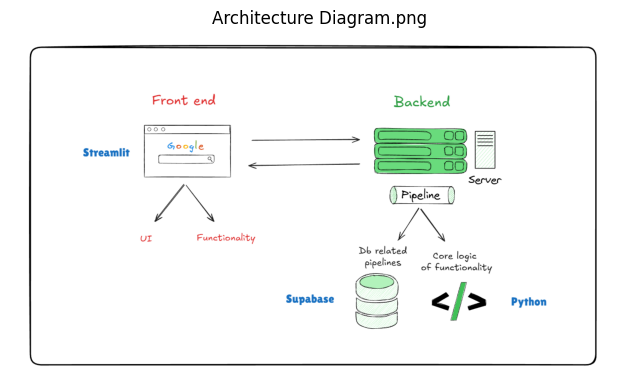

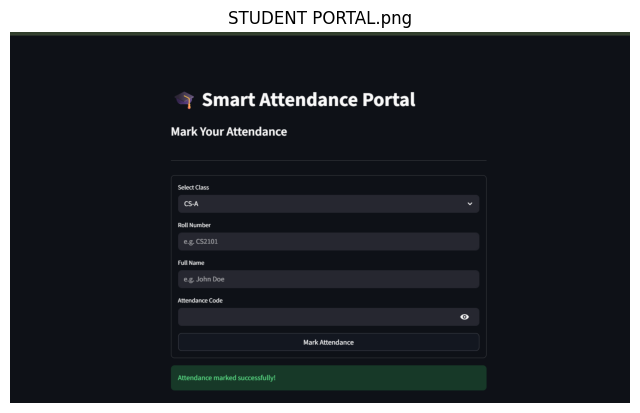

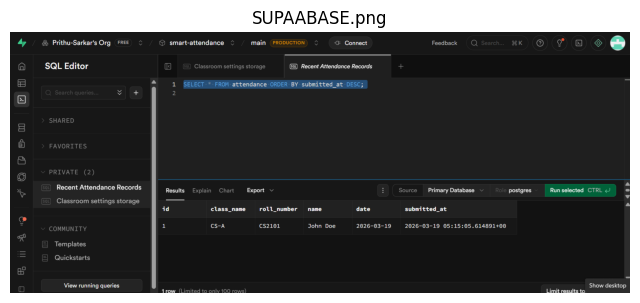

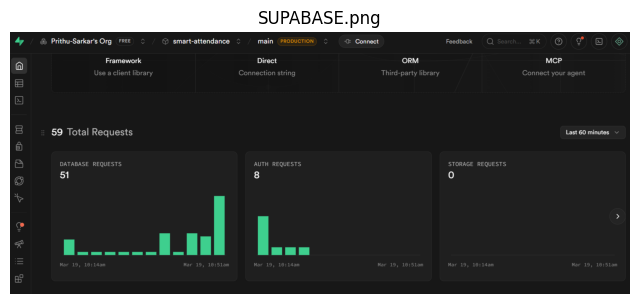

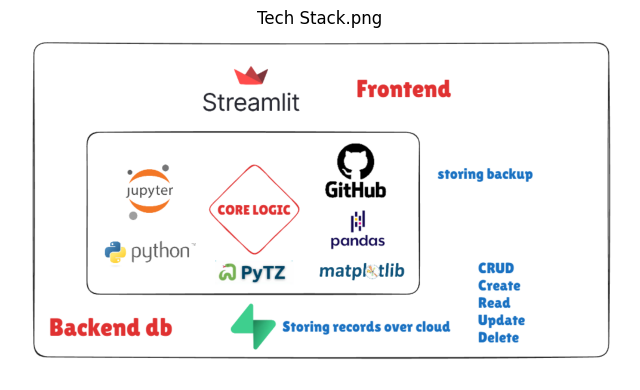

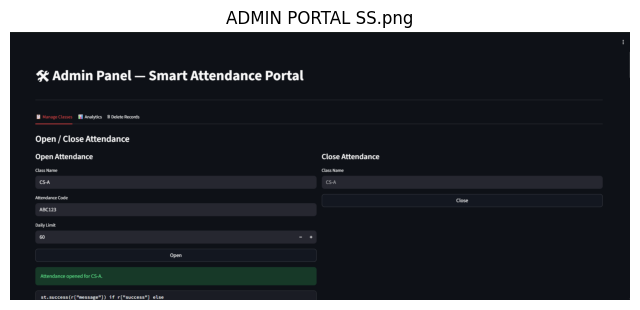

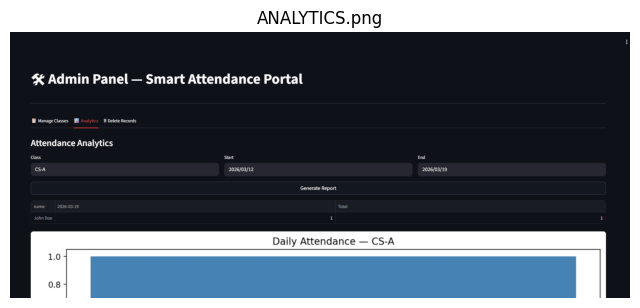

In [28]:
import matplotlib.pyplot as plt
import cv2

image_paths = [
    "/content/Architecture Diagram.png",
    "/content/STUDENT PORTAL.png",
    "/content/SUPAABASE.png",
    "/content/SUPABASE.png",
    "/content/Tech Stack.png",
    "/content/ADMIN PORTAL SS.png",
    "/content/ANALYTICS.png"
]

for path in image_paths:
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,5))
        plt.imshow(img)
        plt.title(path.split("/")[-1])
        plt.axis("off")
        plt.show()
    except:
        print(f"Could not load: {path}")

---
## 🔐 Step 1 — Set Secrets from Colab Secret Manager

In [1]:
# ──────────────────────────────────────────────────────────────────
# Set environment variables from Colab Secrets
# Add your secrets via: Colab left sidebar -> Key icon -> 'Add new secret'
# Keys needed: MONGO_DB_URL, MLFLOW_TRACKING_URI,
#              MLFLOW_TRACKING_USERNAME, MLFLOW_TRACKING_PASSWORD
# ──────────────────────────────────────────────────────────────────
import os
from google.colab import userdata

# MongoDB connection URL (used if you re-enable MongoDB ingestion)
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# MLflow / DagsHub tracking
USE_DAGSHUB = True  # Set to False to log locally inside Colab instead

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow: logs saved to /content/mlruns
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('Env vars set.')
print(f"  MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

# ──────────────────────────────────────────────────────────────────
# Supabase credentials — pulled from Colab Secrets
# Keys needed: SUPABASE_URL, SUPABASE_KEY
# ──────────────────────────────────────────────────────────────────
os.environ['SUPABASE_URL'] = userdata.get('SUPABASE_URL')
os.environ['SUPABASE_KEY'] = userdata.get('SUPABASE_KEY')

print(f"  SUPABASE_URL        = {os.environ['SUPABASE_URL']}")
print('All secrets loaded successfully!')

Env vars set.
  MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow
  SUPABASE_URL        = https://uaqupljuykrovolktpkb.supabase.co
All secrets loaded successfully!


---
## 📦 Step 2 — Install Dependencies

In [2]:
# ──────────────────────────────────────────────────────────────────
# Install all required packages for the Smart Attendance Portal.
# - streamlit  : frontend/UI framework
# - supabase   : Python client for Supabase (PostgreSQL backend)
# - pandas     : data manipulation & CSV export
# - matplotlib : analytics charts
# - pytz       : timezone-aware datetime handling
# - pyngrok    : expose local Streamlit server to the internet
# ──────────────────────────────────────────────────────────────────
!pip install -q streamlit supabase pandas matplotlib pytz pyngrok

---
## 🗂️ Step 3 — Create Project Folder Structure

```
/content/smart_attendance_portal/
├── admin_main.py            ← Admin Streamlit entry point
├── student_main.py          ← Student Streamlit entry point
├── versions.py              ← Version constants
├── requirements.txt
├── .streamlit/
│   └── secrets.toml         ← Supabase keys (written from env vars)
└── Attendence/
    ├── __init__.py
    ├── config.py            ← Central config (URLs, constants)
    ├── logger.py            ← Centralized logging setup
    ├── clients.py           ← Supabase client initialisation
    ├── supabase_client.py   ← Low-level DB helper (CRUD wrappers)
    ├── admin.py             ← Admin business logic
    ├── student.py           ← Student business logic
    ├── analytics.py         ← Attendance analytics & CSV export
    └── utils.py             ← Shared utility functions
```

In [3]:
import os

# ── Define base directory (lives inside Colab runtime, NOT Google Drive) ──
BASE_DIR = '/content/smart_attendance_portal'

# ── Create all required directories ──
dirs = [
    BASE_DIR,
    f'{BASE_DIR}/.streamlit',
    f'{BASE_DIR}/Attendence',
    f'{BASE_DIR}/logs',
    f'{BASE_DIR}/exports',
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'Created: {d}')

print('Project skeleton ready!')

Created: /content/smart_attendance_portal
Created: /content/smart_attendance_portal/.streamlit
Created: /content/smart_attendance_portal/Attendence
Created: /content/smart_attendance_portal/logs
Created: /content/smart_attendance_portal/exports
Project skeleton ready!


---
## 📝 Step 4 — Write All Source Files

In [4]:
# ──────────────────────────────────────────────────────────────────
# .streamlit/secrets.toml
# Streamlit reads this for secret keys — populated from env vars.
# ──────────────────────────────────────────────────────────────────
secrets_toml = f"""
[supabase]
url = \"{os.environ.get('SUPABASE_URL', '')}\"
key = \"{os.environ.get('SUPABASE_KEY', '')}\"
"""

with open(f'{BASE_DIR}/.streamlit/secrets.toml', 'w') as f:
    f.write(secrets_toml)
print('secrets.toml written')

secrets.toml written


In [5]:
# ── versions.py ──────────────────────────────────────────────────
versions_py = '''
VERSION  = "1.0.0"
APP_NAME = "Smart Attendance Portal"
AUTHOR   = "Smart Attendance Team"
'''
with open(f'{BASE_DIR}/versions.py', 'w') as f:
    f.write(versions_py)
print('versions.py written')

versions.py written


In [6]:
# ── requirements.txt ─────────────────────────────────────────────
req = 'streamlit>=1.32.0\nsupabase>=2.3.0\npandas>=2.0.0\nmatplotlib>=3.8.0\npytz>=2024.1\n'
with open(f'{BASE_DIR}/requirements.txt', 'w') as f:
    f.write(req)
print('requirements.txt written')

requirements.txt written


In [7]:
# ── Attendence/__init__.py ────────────────────────────────────────
# Marks the folder as a package and exposes key symbols.
init_py = '''
from .logger          import get_logger
from .clients         import get_supabase_client
from .supabase_client import SupabaseClient
'''
with open(f'{BASE_DIR}/Attendence/__init__.py', 'w') as f:
    f.write(init_py)
print('__init__.py written')

__init__.py written


In [8]:
# ── Attendence/config.py ─────────────────────────────────────────
# Central configuration — all constants in one place.
config_py = '''
import os

# Supabase credentials (from env vars set in Step 1)
SUPABASE_URL = os.environ.get("SUPABASE_URL", "")
SUPABASE_KEY = os.environ.get("SUPABASE_KEY", "")

# Supabase table names
TABLE_ATTENDANCE         = "attendance"
TABLE_ROLL_MAP           = "roll_map"
TABLE_CLASSROOM_SETTINGS = "classroom_settings"

# Application constants
DEFAULT_TIMEZONE     = "Asia/Kolkata"   # IST
MAX_ATTENDANCE_PER_DAY = 60
LOG_DIR              = "logs"
LOG_FILE             = "attendance.log"
CSV_EXPORT_DIR       = "exports"
'''
with open(f'{BASE_DIR}/Attendence/config.py', 'w') as f:
    f.write(config_py)
print('config.py written')

config.py written


In [9]:
# ── Attendence/logger.py ─────────────────────────────────────────
# Centralised logging: console + rotating file handler.
# Each log line shows: timestamp | level | filename:line | message
logger_py = '''
import logging
import os
from logging.handlers import RotatingFileHandler
from .config import LOG_DIR, LOG_FILE

def get_logger(name: str, level: int = logging.DEBUG) -> logging.Logger:
    """Return a named logger writing to console and rotating file."""
    os.makedirs(LOG_DIR, exist_ok=True)
    log_path  = os.path.join(LOG_DIR, LOG_FILE)
    fmt       = "%(asctime)s | %(levelname)-8s | %(filename)s:%(lineno)d | %(message)s"
    formatter = logging.Formatter(fmt, datefmt="%Y-%m-%d %H:%M:%S")
    logger    = logging.getLogger(name)
    logger.setLevel(level)
    if logger.handlers:
        return logger   # avoid duplicate handlers on re-import
    ch = logging.StreamHandler()
    ch.setFormatter(formatter)
    logger.addHandler(ch)
    fh = RotatingFileHandler(log_path, maxBytes=5*1024*1024, backupCount=3)
    fh.setFormatter(formatter)
    logger.addHandler(fh)
    return logger
'''
with open(f'{BASE_DIR}/Attendence/logger.py', 'w') as f:
    f.write(logger_py)
print('logger.py written')

logger.py written


In [10]:
# ── Attendence/clients.py ────────────────────────────────────────
# Module-level singleton Supabase client — one connection per process.
clients_py = '''
from supabase import create_client, Client
from .config  import SUPABASE_URL, SUPABASE_KEY
from .logger  import get_logger

log = get_logger(__name__)
_supabase_client = None

def get_supabase_client() -> Client:
    """Return shared Supabase client, creating it on first call."""
    global _supabase_client
    if _supabase_client is not None:
        return _supabase_client
    if not SUPABASE_URL or not SUPABASE_KEY:
        raise ValueError("Missing Supabase credentials. Check Colab Secrets.")
    try:
        log.info(f"Connecting to Supabase...")
        _supabase_client = create_client(SUPABASE_URL, SUPABASE_KEY)
        log.info("Supabase client initialised.")
    except Exception as e:
        log.exception(f"Supabase connection failed: {e}")
        raise
    return _supabase_client
'''
with open(f'{BASE_DIR}/Attendence/clients.py', 'w') as f:
    f.write(clients_py)
print('clients.py written')

clients.py written


In [11]:
# ── Attendence/supabase_client.py ────────────────────────────────
# CRUD wrappers. All DB calls go here — keeps business logic clean.
sc_py = '''
from .clients import get_supabase_client
from .config  import TABLE_ATTENDANCE, TABLE_ROLL_MAP, TABLE_CLASSROOM_SETTINGS
from .logger  import get_logger

log = get_logger(__name__)

class SupabaseClient:
    def __init__(self):
        self.db = get_supabase_client()

    # ── Classroom settings ────────────────────────────────────
    def get_all_classes(self):
        try:
            return self.db.table(TABLE_CLASSROOM_SETTINGS).select("*").execute().data
        except Exception as e:
            log.exception(e); return []

    def get_class_settings(self, class_name):
        try:
            return self.db.table(TABLE_CLASSROOM_SETTINGS).select("*").eq("class_name", class_name).single().execute().data
        except Exception:
            return None

    def upsert_class_settings(self, payload):
        try:
            self.db.table(TABLE_CLASSROOM_SETTINGS).upsert(payload).execute()
            return True
        except Exception as e:
            log.exception(e); return False

    # ── Roll-number map ───────────────────────────────────────
    def get_roll_entry(self, class_name, roll_number):
        try:
            return self.db.table(TABLE_ROLL_MAP).select("*").eq("class_name", class_name).eq("roll_number", roll_number).single().execute().data
        except Exception:
            return None

    def lock_roll_number(self, class_name, roll_number, name):
        try:
            self.db.table(TABLE_ROLL_MAP).insert({"class_name": class_name, "roll_number": roll_number, "name": name}).execute()
            return True
        except Exception as e:
            log.exception(e); return False

    # ── Attendance records ────────────────────────────────────
    def check_already_marked(self, class_name, roll_number, date_str):
        try:
            res = self.db.table(TABLE_ATTENDANCE).select("id").eq("class_name", class_name).eq("roll_number", roll_number).eq("date", date_str).execute()
            return len(res.data) > 0
        except Exception as e:
            log.exception(e); return False

    def count_today_attendance(self, class_name, date_str):
        try:
            res = self.db.table(TABLE_ATTENDANCE).select("id", count="exact").eq("class_name", class_name).eq("date", date_str).execute()
            return res.count or 0
        except Exception as e:
            log.exception(e); return 0

    def insert_attendance(self, payload):
        try:
            self.db.table(TABLE_ATTENDANCE).insert(payload).execute()
            log.info(f"Inserted: {payload}"); return True
        except Exception as e:
            log.exception(e); return False

    def fetch_attendance_range(self, class_name, start_date, end_date):
        try:
            return self.db.table(TABLE_ATTENDANCE).select("*").eq("class_name", class_name).gte("date", start_date).lte("date", end_date).execute().data
        except Exception as e:
            log.exception(e); return []

    def delete_attendance_record(self, record_id):
        try:
            self.db.table(TABLE_ATTENDANCE).delete().eq("id", record_id).execute()
            return True
        except Exception as e:
            log.exception(e); return False
'''
with open(f'{BASE_DIR}/Attendence/supabase_client.py', 'w') as f:
    f.write(sc_py)
print('supabase_client.py written')

supabase_client.py written


In [12]:
# ── Attendence/utils.py ──────────────────────────────────────────
# Shared helpers: timezone-aware date, input sanitisation, validation.
utils_py = '''
from datetime import datetime
import pytz
from .config import DEFAULT_TIMEZONE
from .logger import get_logger

log = get_logger(__name__)

def get_today_date() -> str:
    """Return today in YYYY-MM-DD using the configured timezone."""
    tz    = pytz.timezone(DEFAULT_TIMEZONE)
    today = datetime.now(tz).strftime("%Y-%m-%d")
    log.debug(f"Today: {today}")
    return today

def get_now_timestamp() -> str:
    """Return current datetime as ISO-8601 string with timezone."""
    return datetime.now(pytz.timezone(DEFAULT_TIMEZONE)).isoformat()

def sanitize_input(value: str) -> str:
    """Strip whitespace and uppercase — normalises codes and roll numbers."""
    return value.strip().upper()

def validate_roll_number(roll: str) -> bool:
    """True if roll is non-empty and alphanumeric (dashes/underscores allowed)."""
    roll = roll.strip()
    return bool(roll) and roll.replace("-","").replace("_","").isalnum()

def validate_name(name: str) -> bool:
    """True if name is non-empty and contains only letters and spaces."""
    name = name.strip()
    return bool(name) and all(c.isalpha() or c.isspace() for c in name)
'''
with open(f'{BASE_DIR}/Attendence/utils.py', 'w') as f:
    f.write(utils_py)
print('utils.py written')

utils.py written


In [13]:
# ── Attendence/student.py ────────────────────────────────────────
# Core student attendance flow with 7-step validation pipeline:
#   1. Input sanitisation   5. Roll-number/name locking
#   2. Class is open        6. Duplicate check
#   3. Daily limit check    7. Insert record
#   4. Code verification
student_py = '''
from .logger          import get_logger
from .supabase_client import SupabaseClient
from .utils           import get_today_date, get_now_timestamp, sanitize_input, validate_name, validate_roll_number

log = get_logger(__name__)

def mark_attendance(class_name, roll_number, name, entered_code) -> dict:
    db    = SupabaseClient()
    today = get_today_date()

    # 1. Sanitise & validate
    roll_number  = sanitize_input(roll_number)
    name         = name.strip().title()
    entered_code = sanitize_input(entered_code)
    if not validate_roll_number(roll_number):
        return {"success": False, "message": "Invalid roll number format."}
    if not validate_name(name):
        return {"success": False, "message": "Invalid name — letters only."}

    # 2. Class settings & open check
    settings = db.get_class_settings(class_name)
    if not settings:
        return {"success": False, "message": f"Class not found."}
    if not settings.get("attendance_open", False):
        return {"success": False, "message": "Attendance is closed for this class."}

    # 3. Daily limit check
    limit = settings.get("daily_limit", 60)
    count = db.count_today_attendance(class_name, today)
    if count >= limit:
        return {"success": False, "message": "Daily attendance limit reached."}

    # 4. Code verification
    if entered_code != sanitize_input(settings.get("attendance_code", "")):
        return {"success": False, "message": "Incorrect attendance code."}

    # 5. Roll-number/name locking
    existing = db.get_roll_entry(class_name, roll_number)
    if existing:
        if name.lower() != existing["name"].lower():
            return {"success": False, "message": f"Roll {roll_number} belongs to \'{existing[chr(34)+chr(110)+chr(97)+chr(109)+chr(101)+chr(34)]}.\' Name mismatch."}
    else:
        db.lock_roll_number(class_name, roll_number, name)

    # 6. Duplicate check
    if db.check_already_marked(class_name, roll_number, today):
        return {"success": False, "message": "Attendance already marked today."}

    # 7. Insert
    ok = db.insert_attendance({"class_name": class_name, "roll_number": roll_number,
                               "name": name, "date": today, "submitted_at": get_now_timestamp()})
    if ok:
        log.info(f"Marked: {roll_number}|{name}|{class_name}|{today}")
        return {"success": True, "message": "Attendance marked successfully!"}
    return {"success": False, "message": "Database error. Try again."}
'''
with open(f'{BASE_DIR}/Attendence/student.py', 'w') as f:
    f.write(student_py)
print('student.py written')

student.py written


In [14]:
# ── Attendence/admin.py ──────────────────────────────────────────
# Admin business logic: open/close attendance, daily summary, delete.
admin_py = '''
from .logger          import get_logger
from .supabase_client import SupabaseClient
from .utils           import get_today_date, sanitize_input

log = get_logger(__name__)

def open_attendance(class_name, code, daily_limit) -> dict:
    """Open attendance for a class — sets code, limit, and open=True."""
    db   = SupabaseClient()
    code = sanitize_input(code)
    if not code:
        return {"success": False, "message": "Code cannot be empty."}
    if daily_limit < 1:
        return {"success": False, "message": "Limit must be >= 1."}
    ok = db.upsert_class_settings({"class_name": class_name, "attendance_code": code,
                                    "daily_limit": daily_limit, "attendance_open": True})
    if ok:
        log.info(f"OPENED {class_name} code={code} limit={daily_limit}")
        return {"success": True, "message": f"Attendance opened for {class_name}."}
    return {"success": False, "message": "Failed to open attendance."}

def close_attendance(class_name) -> dict:
    """Close attendance — students can no longer submit."""
    db       = SupabaseClient()
    settings = db.get_class_settings(class_name)
    if not settings:
        return {"success": False, "message": f"Class not found."}
    settings["attendance_open"] = False
    ok = db.upsert_class_settings(settings)
    if ok:
        log.info(f"CLOSED {class_name}")
        return {"success": True, "message": f"Attendance closed for {class_name}."}
    return {"success": False, "message": "Failed to close attendance."}

def get_today_summary(class_name) -> dict:
    """Return dict with today count, limit, and open status."""
    db       = SupabaseClient()
    today    = get_today_date()
    settings = db.get_class_settings(class_name) or {}
    return {"class_name": class_name, "date": today,
            "count": db.count_today_attendance(class_name, today),
            "limit": settings.get("daily_limit", 0),
            "is_open": settings.get("attendance_open", False)}

def delete_record(record_id) -> dict:
    """Delete a specific attendance record by primary key."""
    db = SupabaseClient()
    if db.delete_attendance_record(record_id):
        log.info(f"Deleted record id={record_id}")
        return {"success": True, "message": f"Record {record_id} deleted."}
    return {"success": False, "message": "Delete failed."}
'''
with open(f'{BASE_DIR}/Attendence/admin.py', 'w') as f:
    f.write(admin_py)
print('admin.py written')

admin.py written


In [15]:
# ── Attendence/analytics.py ──────────────────────────────────────
# Builds pivot-table attendance matrices and exports to CSV.
analytics_py = '''
import os
import pandas as pd
from .config          import CSV_EXPORT_DIR
from .logger          import get_logger
from .supabase_client import SupabaseClient

log = get_logger(__name__)

def build_attendance_matrix(class_name, start_date, end_date) -> pd.DataFrame:
    """
    Pivot table: rows=students, columns=dates, values=1(present)/0(absent).
    Adds a Total column at the end.
    """
    db      = SupabaseClient()
    records = db.fetch_attendance_range(class_name, start_date, end_date)
    if not records:
        log.warning(f"No records for {class_name} [{start_date} to {end_date}]")
        return pd.DataFrame()
    df = pd.DataFrame(records)
    df["present"] = 1
    matrix = df.pivot_table(index="name", columns="date", values="present",
                             aggfunc="max", fill_value=0)
    matrix["Total"] = matrix.sum(axis=1)
    log.info(f"Matrix: {matrix.shape[0]} students x {matrix.shape[1]-1} days")
    return matrix

def export_matrix_to_csv(matrix, class_name, start_date, end_date) -> str:
    """Save matrix to CSV and return the file path."""
    os.makedirs(CSV_EXPORT_DIR, exist_ok=True)
    path = os.path.join(CSV_EXPORT_DIR, f"{class_name}_{start_date}_to_{end_date}.csv")
    matrix.to_csv(path)
    log.info(f"Exported: {path}")
    return path

def daily_counts(class_name, start_date, end_date) -> pd.Series:
    """Count of students present per day — used for bar/line charts."""
    db      = SupabaseClient()
    records = db.fetch_attendance_range(class_name, start_date, end_date)
    if not records:
        return pd.Series(dtype=int)
    df = pd.DataFrame(records)
    return df.groupby("date")["roll_number"].count().sort_index()
'''
with open(f'{BASE_DIR}/Attendence/analytics.py', 'w') as f:
    f.write(analytics_py)
print('analytics.py written')

analytics.py written


In [16]:
# ── student_main.py ──────────────────────────────────────────────
# Streamlit entry point for the student portal.
# Run with: streamlit run student_main.py
student_main_py = '''
import sys, os
sys.path.insert(0, os.path.dirname(__file__))

import streamlit as st
from Attendence.student         import mark_attendance
from Attendence.supabase_client import SupabaseClient
from Attendence.logger          import get_logger

log = get_logger(__name__)

st.set_page_config(page_title="Attendance Portal — Student", page_icon="🎓", layout="centered")
st.title("🎓 Smart Attendance Portal")
st.subheader("Mark Your Attendance")
st.divider()

@st.cache_data(ttl=60)
def load_open_classes():
    """Load classes that are currently open — refresh every 60 s."""
    db = SupabaseClient()
    return [c["class_name"] for c in db.get_all_classes() if c.get("attendance_open")]

open_classes = load_open_classes()
if not open_classes:
    st.warning("No classes are currently open for attendance.")
    st.stop()

with st.form("attendance_form", clear_on_submit=True):
    class_name   = st.selectbox("Select Class", open_classes)
    roll_number  = st.text_input("Roll Number", placeholder="e.g. CS2101")
    name         = st.text_input("Full Name",   placeholder="e.g. John Doe")
    entered_code = st.text_input("Attendance Code", type="password")
    submitted    = st.form_submit_button("Mark Attendance", use_container_width=True)

if submitted:
    with st.spinner("Submitting..."):
        result = mark_attendance(class_name, roll_number, name, entered_code)
    if result["success"]:
        st.success(result["message"])
        st.balloons()
    else:
        st.error(result["message"])
'''
with open(f'{BASE_DIR}/student_main.py', 'w') as f:
    f.write(student_main_py)
print('student_main.py written')

student_main.py written


In [24]:
# ── Fix admin_main.py — rewrite the Today Summary section cleanly ──
fix = '''
import io, sys, os
from datetime import date, timedelta
sys.path.insert(0, os.path.dirname(__file__))

import matplotlib.pyplot as plt
import streamlit as st
from Attendence.admin           import close_attendance, get_today_summary, open_attendance, delete_record
from Attendence.analytics       import build_attendance_matrix, daily_counts
from Attendence.supabase_client import SupabaseClient
from Attendence.logger          import get_logger

log = get_logger(__name__)

st.set_page_config(page_title="Attendance Portal — Admin", page_icon="🛠", layout="wide")
st.title("🛠 Admin Panel — Smart Attendance Portal")
st.divider()

tab1, tab2, tab3 = st.tabs(["📋 Manage Classes", "📊 Analytics", "🗑 Delete Records"])

# ── TAB 1: Manage Classes ─────────────────────────────────────────
with tab1:
    st.subheader("Open / Close Attendance")
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("#### Open Attendance")
        cn  = st.text_input("Class Name", key="oc", placeholder="CS-A")
        cd  = st.text_input("Attendance Code", key="ocd")
        lim = st.number_input("Daily Limit", min_value=1, max_value=500, value=60, key="ol")
        if st.button("Open", use_container_width=True):
            r = open_attendance(cn, cd, lim)
            st.success(r["message"]) if r["success"] else st.error(r["message"])

    with col2:
        st.markdown("#### Close Attendance")
        cc = st.text_input("Class Name", key="cc", placeholder="CS-A")
        if st.button("Close", use_container_width=True):
            r = close_attendance(cc)
            st.success(r["message"]) if r["success"] else st.error(r["message"])

    st.divider()
    st.subheader("Today Summary")
    db = SupabaseClient()
    all_classes = db.get_all_classes()
    if all_classes:
        for cls in all_classes:
            name = cls["class_name"]
            s = get_today_summary(name)
            status = "🟢 Open" if s["is_open"] else "🔴 Closed"
            st.metric(
                label=f"{name} — {status}",
                value=f"{s['count']} / {s['limit']} students"
            )
    else:
        st.info("No classes found.")

# ── TAB 2: Analytics ──────────────────────────────────────────────
with tab2:
    st.subheader("Attendance Analytics")
    ca, cb, cc2 = st.columns(3)
    with ca: acls = st.text_input("Class", key="acls")
    with cb: s_dt = st.date_input("Start", value=date.today()-timedelta(days=7), key="sdt")
    with cc2: e_dt = st.date_input("End",  value=date.today(), key="edt")

    if st.button("Generate Report", use_container_width=True):
        s_str, e_str = s_dt.strftime("%Y-%m-%d"), e_dt.strftime("%Y-%m-%d")
        with st.spinner("Fetching..."):
            matrix = build_attendance_matrix(acls, s_str, e_str)
        if matrix.empty:
            st.warning("No records found.")
        else:
            st.dataframe(matrix, use_container_width=True)
            counts = daily_counts(acls, s_str, e_str)
            if not counts.empty:
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.bar(counts.index, counts.values, color="steelblue")
                ax.set(xlabel="Date", ylabel="Present", title=f"Daily Attendance — {acls}")
                plt.xticks(rotation=45, ha="right")
                plt.tight_layout()
                st.pyplot(fig)
            buf = io.StringIO()
            matrix.to_csv(buf)
            st.download_button("⬇️ Download CSV", buf.getvalue(),
                               file_name=f"{acls}_{s_str}_to_{e_str}.csv",
                               mime="text/csv", use_container_width=True)

# ── TAB 3: Delete Records ─────────────────────────────────────────
with tab3:
    st.subheader("Delete Attendance Record")
    st.warning("This action is permanent.")
    rid = st.number_input("Record ID", min_value=1, step=1, key="rid")
    if st.button("Delete", use_container_width=True):
        r = delete_record(int(rid))
        st.success(r["message"]) if r["success"] else st.error(r["message"])
'''

with open(f'{BASE_DIR}/admin_main.py', 'w') as f:
    f.write(fix)

print('✅ admin_main.py fixed!')

✅ admin_main.py fixed!


In [25]:
# ── Verify the complete project structure was created correctly ──
import os
print('Project structure:')
for root, dirs, files in os.walk(BASE_DIR):
    dirs[:] = [d for d in dirs if d not in ('__pycache__',)]
    level  = root.replace(BASE_DIR, '').count(os.sep)
    indent = '    ' * level
    print(f'{indent}📂 {os.path.basename(root)}/')
    for f in sorted(files):
        print(f'{indent}    📄 {f}')
print('All files written!')

Project structure:
📂 smart_attendance_portal/
    📄 admin_main.py
    📄 requirements.txt
    📄 student_main.py
    📄 versions.py
    📂 .streamlit/
        📄 secrets.toml
    📂 exports/
    📂 Attendence/
        📄 __init__.py
        📄 admin.py
        📄 analytics.py
        📄 clients.py
        📄 config.py
        📄 logger.py
        📄 student.py
        📄 supabase_client.py
        📄 utils.py
    📂 logs/
All files written!


---
## 🗃️ Step 5 — Supabase Table Setup

Run this SQL in your **Supabase SQL Editor** (supabase.com → your project → SQL Editor):

```sql
-- Table 1: classroom_settings
CREATE TABLE IF NOT EXISTS classroom_settings (
    id               SERIAL PRIMARY KEY,
    class_name       TEXT UNIQUE NOT NULL,
    attendance_code  TEXT NOT NULL DEFAULT '',
    daily_limit      INTEGER NOT NULL DEFAULT 60,
    attendance_open  BOOLEAN NOT NULL DEFAULT FALSE,
    created_at       TIMESTAMPTZ DEFAULT NOW()
);

-- Table 2: roll_map (locks roll numbers to student names)
CREATE TABLE IF NOT EXISTS roll_map (
    id           SERIAL PRIMARY KEY,
    class_name   TEXT NOT NULL,
    roll_number  TEXT NOT NULL,
    name         TEXT NOT NULL,
    UNIQUE(class_name, roll_number)
);

-- Table 3: attendance (one row per student per day)
CREATE TABLE IF NOT EXISTS attendance (
    id           SERIAL PRIMARY KEY,
    class_name   TEXT NOT NULL,
    roll_number  TEXT NOT NULL,
    name         TEXT NOT NULL,
    date         DATE NOT NULL,
    submitted_at TIMESTAMPTZ DEFAULT NOW(),
    UNIQUE(class_name, roll_number, date)  -- DB-level duplicate guard
);
```

---
## 🚀 Step 6 — Launch the App

Run **one** of the two cells below.

In [21]:
import subprocess, time
from pyngrok import ngrok
from google.colab import userdata

PORT = 8501

# ── Authenticate ngrok using your Colab secret ────────────────────
ngrok.set_auth_token(userdata.get('NGROK_AUTHTOKEN'))

# Start Streamlit in background
process = subprocess.Popen(
    ['streamlit', 'run', f'{BASE_DIR}/student_main.py',
     '--server.port', str(PORT),
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(4)  # Wait for Streamlit to boot

# Open public tunnel
public_url = ngrok.connect(PORT)
print(f'Student Portal LIVE: {public_url}')
print('Share this URL with students during class.')

Student Portal LIVE: NgrokTunnel: "https://nuggety-zeke-buckishly.ngrok-free.dev" -> "http://localhost:8501"
Share this URL with students during class.


In [23]:
import subprocess, time
from pyngrok import ngrok
from google.colab import userdata

PORT = 8501
ngrok.kill()

# ── Authenticate ngrok using your Colab secret ────────────────────
ngrok.set_auth_token(userdata.get('NGROK_AUTHTOKEN'))

process = subprocess.Popen(
    ['streamlit', 'run', f'{BASE_DIR}/admin_main.py',
     '--server.port', str(PORT),
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(4)

public_url = ngrok.connect(PORT)
print(f'Admin Portal LIVE: {public_url}')
print('Keep this URL private — admin use only.')

Admin Portal LIVE: NgrokTunnel: "https://nuggety-zeke-buckishly.ngrok-free.dev" -> "http://localhost:8501"
Keep this URL private — admin use only.


---
## 🛑 Step 7 — Stop the App

In [22]:
# ── Gracefully shut down the tunnel and Streamlit process ───────
from pyngrok import ngrok
ngrok.kill()        # Close the public tunnel
process.terminate() # Stop the Streamlit subprocess
print('App stopped. Tunnel closed.')

App stopped. Tunnel closed.


In [26]:
import shutil
from google.colab import files

# Define folder path and output zip name
folder_path = '/content/smart_attendance_portal'
zip_path = '/content/smart_attendance_portal.zip'

# Create zip file
shutil.make_archive('/content/smart_attendance_portal', 'zip', folder_path)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>